# 02 - Baseline Model Experiments

This notebook trains and evaluates baseline plate-recognition CNN experiments. It covers clean and augmented training, prediction export, error analysis, stress testing, 64x192 image-size experiments, API-flow checks, and late project-building diagnostics.

## Contents

1. Setup and reusable helpers
2. Clean 48x160 baseline
3. Test-set prediction export and error analysis
4. Augmented 48x160 baseline
5. Stress testing 48x160 models
6. Clean and augmented 64x192 experiments
7. Stress testing 64x192 models
8. API-flow and legacy integration checks
9. Dataset diagnostics and debug utilities


## 1. Setup and Reusable Helpers


In [19]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"Argument\(s\) 'var_limit'.*GaussNoise",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=r"Argument\(s\) 'quality_lower, quality_upper'.*ImageCompression",
    category=UserWarning,
)

from pathlib import Path
import hashlib
import re
import sys
from collections import Counter
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from torch.utils.data import DataLoader

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from anpr.data.dataset import PlateDataset
from anpr.data.encoders import INDEX_TO_CHAR
from anpr.data.transforms import get_eval_transforms, get_stress_test_transforms, get_train_transforms
from anpr.evaluation.metrics import format_plate_metrics
from anpr.inference.decode import decode_model_outputs
from anpr.inference.pipeline import ANPRPipeline
from anpr.inference.predict import PlateRecognizer
from anpr.models.plate_cnn import PlateCNN, count_trainable_parameters
from anpr.training.losses import PlateMultiHeadLoss
from anpr.training.train_loop import evaluate_one_epoch, train_one_epoch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates.csv"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "baseline_cnn"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "predictions"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.1
POOLED_WIDTH = 10
PLATE_LENGTH = 7

print("Device:", DEVICE)


Device: cpu


In [2]:
def build_datasets(image_height: int, image_width: int, train_augmented: bool = False):
    train_transform = (
        get_train_transforms(image_height=image_height, image_width=image_width)
        if train_augmented
        else get_eval_transforms(image_height=image_height, image_width=image_width)
    )
    eval_transform = get_eval_transforms(image_height=image_height, image_width=image_width)

    def dataset_for(split: str, transform):
        return PlateDataset(
            metadata=METADATA_CSV,
            project_root=PROJECT_ROOT,
            split=split,
            transform=transform,
            grayscale=True,
        )

    return dataset_for("train", train_transform), dataset_for("val", eval_transform), dataset_for("test", eval_transform)


def make_loaders(train_ds, val_ds, test_ds, batch_size: int = BATCH_SIZE):
    kwargs = {"batch_size": batch_size, "num_workers": 0, "pin_memory": torch.cuda.is_available()}
    return (
        DataLoader(train_ds, shuffle=True, **kwargs),
        DataLoader(val_ds, shuffle=False, **kwargs),
        DataLoader(test_ds, shuffle=False, **kwargs),
    )


def build_model():
    return PlateCNN(in_channels=1, dropout=DROPOUT, pooled_width=POOLED_WIDTH).to(DEVICE)


def history_row(epoch: int, train_result, val_result) -> dict[str, Any]:
    metrics = val_result.metrics
    row = {
        "epoch": epoch,
        "train_loss": train_result.loss,
        "val_loss": val_result.loss,
        "val_full_plate_accuracy": metrics.full_plate_accuracy,
        "val_regex_valid_rate": metrics.regex_valid_rate,
        "val_average_confidence": metrics.average_confidence,
    }
    for position, acc in enumerate(metrics.per_position_accuracy):
        row[f"val_position_{position}_acc"] = acc
    return row


def train_experiment(model, train_loader, val_loader, checkpoint_path: Path, image_height: int, image_width: int, num_epochs: int):
    loss_fn = PlateMultiHeadLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best_val_accuracy = 0.0
    history = []

    for epoch in range(1, num_epochs + 1):
        train_result = train_one_epoch(model, train_loader, loss_fn, optimizer, DEVICE, show_progress=True)
        val_result = evaluate_one_epoch(model, val_loader, loss_fn, DEVICE, show_progress=True)
        row = history_row(epoch, train_result, val_result)
        history.append(row)

        print(
            f"Epoch {epoch:02d} | train_loss={train_result.loss:.4f} | "
            f"val_loss={val_result.loss:.4f} | val_full_plate_acc={row['val_full_plate_accuracy']:.4f} | "
            f"confidence={row['val_average_confidence']:.4f}"
        )

        if row["val_full_plate_accuracy"] > best_val_accuracy:
            best_val_accuracy = row["val_full_plate_accuracy"]
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "epoch": epoch,
                    "best_val_accuracy": best_val_accuracy,
                    "history": history,
                    "model_config": {
                        "in_channels": 1,
                        "dropout": DROPOUT,
                        "pooled_width": POOLED_WIDTH,
                        "image_height": image_height,
                        "image_width": image_width,
                        "grayscale": True,
                    },
                },
                checkpoint_path,
            )
            print("Saved new best checkpoint:", checkpoint_path)

    return pd.DataFrame(history)


def save_history(history_df: pd.DataFrame, filename: str) -> None:
    path = OUTPUT_DIR / filename
    history_df.to_csv(path, index=False)
    print("Saved history:", path)


def plot_history(history_df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["val_full_plate_accuracy"], label="Val full-plate accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} validation accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    for position in range(PLATE_LENGTH):
        plt.plot(history_df["epoch"], history_df[f"val_position_{position}_acc"], label=f"position_{position}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} per-position validation accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()


def load_checkpoint_model(checkpoint_path: Path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    config = checkpoint["model_config"]
    model = PlateCNN(
        in_channels=config["in_channels"],
        dropout=config["dropout"],
        pooled_width=config["pooled_width"],
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


def evaluate_model(model, loader, label: str):
    result = evaluate_one_epoch(model, loader, PlateMultiHeadLoss(), DEVICE, show_progress=True)
    print(f"{label} loss:", result.loss)
    print(format_plate_metrics(result.metrics))
    return result


def export_predictions(model, loader, filename: str) -> pd.DataFrame:
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE)
            labels = list(batch["label"])
            image_paths = list(batch["image_path"])
            predictions = decode_model_outputs(model(images))

            for image_path, true_label, prediction in zip(image_paths, labels, predictions):
                predicted_label = prediction.cleaned_prediction
                row = {
                    "image_path": image_path,
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "correct": predicted_label == true_label,
                    "confidence": prediction.overall_confidence,
                    "regex_valid": prediction.is_valid_format,
                }
                for position in range(PLATE_LENGTH):
                    row[f"true_pos_{position}"] = true_label[position]
                    row[f"pred_pos_{position}"] = predicted_label[position]
                    row[f"pos_{position}_correct"] = true_label[position] == predicted_label[position]
                    row[f"pos_{position}_confidence"] = prediction.position_confidences[position]
                rows.append(row)

    df = pd.DataFrame(rows)
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print("Saved predictions:", path)
    return df


def show_decoded_predictions(model, loader, max_rows: int = 20) -> None:
    model.eval()
    batch = next(iter(loader))
    labels = list(batch["label"])
    with torch.no_grad():
        predictions = decode_model_outputs(model(batch["image"].to(DEVICE)))
    for true_label, prediction in zip(labels[:max_rows], predictions[:max_rows]):
        print(
            f"True: {true_label} | Pred: {prediction.cleaned_prediction} | "
            f"Correct: {prediction.cleaned_prediction == true_label} | Conf: {prediction.overall_confidence:.4f}"
        )


def inspect_errors(predictions_df: pd.DataFrame, max_rows: int = 20) -> pd.DataFrame:
    errors_df = predictions_df[~predictions_df["correct"]].copy()
    print("Number of test errors:", len(errors_df))
    print("Test full-plate accuracy:", predictions_df["correct"].mean())
    return errors_df.sort_values("confidence", ascending=False).head(max_rows)


def position_error_summary(predictions_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "position": position,
            "accuracy": predictions_df[f"pos_{position}_correct"].mean(),
            "errors": (~predictions_df[f"pos_{position}_correct"]).sum(),
        }
        for position in range(PLATE_LENGTH)
    )


def character_errors(predictions_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in predictions_df[~predictions_df["correct"]].iterrows():
        for position in range(PLATE_LENGTH):
            true_char = row["true_label"][position]
            pred_char = row["predicted_label"][position]
            if true_char != pred_char:
                rows.append(
                    {
                        "image_path": row["image_path"],
                        "true_label": row["true_label"],
                        "predicted_label": row["predicted_label"],
                        "position": position,
                        "true_char": true_char,
                        "pred_char": pred_char,
                        "plate_confidence": row["confidence"],
                        "position_confidence": row[f"pos_{position}_confidence"],
                    }
                )
    return pd.DataFrame(rows)


In [5]:
def resolve_image_path(path_value) -> Path:
    path = Path(path_value)
    return path if path.is_absolute() else PROJECT_ROOT / path


def show_error_images(errors_df: pd.DataFrame, max_images: int = 12) -> None:
    rows = errors_df.head(max_images).reset_index(drop=True)
    if rows.empty:
        print("No images to display.")
        return

    cols = 3
    plot_rows = (len(rows) + cols - 1) // cols
    plt.figure(figsize=(14, 3.6 * plot_rows), dpi=90)

    for index, row in rows.iterrows():
        image_path = resolve_image_path(row["image_path"])
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            print("Could not read image:", image_path)
            continue
        plt.subplot(plot_rows, cols, index + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.4f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def denormalise_plate_tensor(image_tensor):
    image = image_tensor.squeeze(0).detach().cpu().numpy()
    image = (image * 0.5) + 0.5
    return image.clip(0, 1)


def show_augmented_batch(dataset, num_images: int = 16) -> None:
    loader = DataLoader(dataset, batch_size=num_images, shuffle=True, num_workers=0)
    batch = next(iter(loader))
    plt.figure(figsize=(14, 7), dpi=90)
    for index in range(min(num_images, 16)):
        plt.subplot(4, 4, index + 1)
        plt.imshow(denormalise_plate_tensor(batch["image"][index]), cmap="gray")
        plt.title(batch["label"][index])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def build_stress_loader(image_height: int, image_width: int) -> DataLoader:
    stress_ds = PlateDataset(
        metadata=METADATA_CSV,
        project_root=PROJECT_ROOT,
        split="test",
        transform=get_stress_test_transforms(image_height=image_height, image_width=image_width),
        grayscale=True,
    )
    return DataLoader(
        stress_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


def run_repeated_stress_eval(model, model_name: str, stress_loader: DataLoader, num_runs: int = 5) -> pd.DataFrame:
    rows = []
    for run in range(1, num_runs + 1):
        result = evaluate_one_epoch(model, stress_loader, PlateMultiHeadLoss(), DEVICE, show_progress=True)
        metrics = result.metrics
        row = {
            "model": model_name,
            "run": run,
            "loss": result.loss,
            "full_plate_accuracy": metrics.full_plate_accuracy,
            "regex_valid_rate": metrics.regex_valid_rate,
            "average_confidence": metrics.average_confidence,
        }
        for position, acc in enumerate(metrics.per_position_accuracy):
            row[f"position_{position}_acc"] = acc
        rows.append(row)
        print(f"{model_name} | run {run} | stress_acc={metrics.full_plate_accuracy:.4f} | confidence={metrics.average_confidence:.4f}")
    return pd.DataFrame(rows)


def stress_summary(stress_runs_df: pd.DataFrame) -> pd.DataFrame:
    return (
        stress_runs_df.groupby("model")
        .agg(
            stress_acc_mean=("full_plate_accuracy", "mean"),
            stress_acc_std=("full_plate_accuracy", "std"),
            confidence_mean=("average_confidence", "mean"),
            confidence_std=("average_confidence", "std"),
            loss_mean=("loss", "mean"),
            loss_std=("loss", "std"),
        )
        .reset_index()
    )


def save_stress_outputs(runs_df: pd.DataFrame, summary_df: pd.DataFrame, runs_filename: str, summary_filename: str) -> None:
    runs_df.to_csv(OUTPUT_DIR / runs_filename, index=False)
    summary_df.to_csv(OUTPUT_DIR / summary_filename, index=False)
    print("Saved:", OUTPUT_DIR / runs_filename)
    print("Saved:", OUTPUT_DIR / summary_filename)


## 2. Clean 48x160 Baseline


In [3]:
clean_train_ds, clean_val_ds, clean_test_ds = build_datasets(48, 160, train_augmented=False)
clean_train_loader, clean_val_loader, clean_test_loader = make_loaders(clean_train_ds, clean_val_ds, clean_test_ds)
print("Dataset sizes:", len(clean_train_ds), len(clean_val_ds), len(clean_test_ds))


Dataset sizes: 19200 2400 2400


In [ ]:
clean_48_model = build_model()
clean_48_checkpoint_path = CHECKPOINT_DIR / "plate_cnn_baseline_best.pt"
print("Trainable parameters:", count_trainable_parameters(clean_48_model))
clean_48_history_df = train_experiment(clean_48_model, clean_train_loader, clean_val_loader, clean_48_checkpoint_path, 48, 160, num_epochs=3)


In [ ]:
save_history(clean_48_history_df, "baseline_training_history.csv")
display(clean_48_history_df)
plot_history(clean_48_history_df, "Clean 48x160 baseline")


In [ ]:
show_decoded_predictions(clean_48_model, clean_val_loader, max_rows=20)


## 3. Test-Set Prediction Export and Error Analysis


In [6]:
clean_48_best_model, clean_48_checkpoint = load_checkpoint_model(clean_48_checkpoint_path)
print("Epoch:", clean_48_checkpoint["epoch"])
print("Best validation accuracy:", clean_48_checkpoint["best_val_accuracy"])
print("Model config:", clean_48_checkpoint["model_config"])
clean_48_test_result = evaluate_model(clean_48_best_model, clean_test_loader, "Clean 48x160 test")


Epoch: 2
Best validation accuracy: 0.99625
Model config: {'in_channels': 1, 'dropout': 0.1, 'pooled_width': 10, 'image_height': 48, 'image_width': 160, 'grayscale': True}


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Clean 48x160 test loss: 0.018836233193675677
Samples: 2400
Full-plate accuracy: 0.9950
Regex-valid rate: 1.0000
Average confidence: 0.9845
Per-position accuracy:
  Position 0: 1.0000
  Position 1: 1.0000
  Position 2: 0.9996
  Position 3: 0.9988
  Position 4: 0.9971
  Position 5: 0.9979
  Position 6: 0.9988


In [7]:
clean_48_predictions_df = export_predictions(clean_48_best_model, clean_test_loader, "baseline_test_predictions.csv")
display(clean_48_predictions_df.head())
print("Full-plate accuracy:", clean_48_predictions_df["correct"].mean())


Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\predictions\baseline_test_predictions.csv


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
0,C:\Users\kosko\OneDrive\Python\machine_learnin...,AA39HMS,AA39HMS,True,0.988080,True,A,A,True,0.980634,...,True,0.989045,M,M,True,0.988419,S,S,True,0.980299
1,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB42XID,AB42XID,True,0.982491,True,A,A,True,0.966917,...,True,0.987056,I,I,True,0.997501,D,D,True,0.949292
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB81EXE,AB81EXE,True,0.988167,True,A,A,True,0.965042,...,True,0.999225,X,X,True,0.982817,E,E,True,0.999145
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB88VEK,AB88VEK,True,0.986711,True,A,A,True,0.973695,...,True,0.998364,E,E,True,0.999350,K,K,True,0.985865
4,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC76RNT,AC76RNT,True,0.986701,True,A,A,True,0.983409,...,True,0.976067,N,N,True,0.992834,T,T,True,0.989497


Full-plate accuracy: 0.995


In [8]:
display(inspect_errors(clean_48_predictions_df))
display(position_error_summary(clean_48_predictions_df))
clean_48_char_errors_df = character_errors(clean_48_predictions_df)
display(clean_48_char_errors_df.sort_values(["position", "position_confidence"], ascending=[True, False]).head(30))
display(clean_48_char_errors_df.groupby("position").size().reset_index(name="num_errors"))


Number of test errors: 12
Test full-plate accuracy: 0.995


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
2378,C:\Users\kosko\OneDrive\Python\machine_learnin...,ZO11ZUT,ZO11DUT,False,0.902639,True,Z,Z,True,0.995803,...,False,0.552073,U,U,True,0.907824,T,T,True,0.885665
1619,C:\Users\kosko\OneDrive\Python\machine_learnin...,IT16DOX,IT15DOX,False,0.890470,True,I,I,True,0.997902,...,True,0.991664,O,O,True,0.840349,X,X,True,0.771627
1642,C:\Users\kosko\OneDrive\Python\machine_learnin...,JI31ORP,JI31DRP,False,0.885627,True,J,J,True,0.996473,...,False,0.456871,R,R,True,0.922532,P,P,True,0.839524
453,C:\Users\kosko\OneDrive\Python\machine_learnin...,IX18TCO,IX15TCO,False,0.879734,True,I,I,True,0.997117,...,True,0.946152,C,C,True,0.925348,O,O,True,0.868058
1473,C:\Users\kosko\OneDrive\Python\machine_learnin...,FL11LGA,FL11EGA,False,0.832661,True,F,F,True,0.995122,...,False,0.408374,G,G,True,0.913073,A,A,True,0.514185
1227,C:\Users\kosko\OneDrive\Python\machine_learnin...,ZY11IMU,ZY11IUU,False,0.831122,True,Z,Z,True,0.995412,...,True,0.901036,M,U,False,0.545960,U,U,True,0.388392
2315,C:\Users\kosko\OneDrive\Python\machine_learnin...,YI13MPC,YI13WPC,False,0.815998,True,Y,Y,True,0.990008,...,False,0.449732,P,P,True,0.949416,C,C,True,0.838647
450,C:\Users\kosko\OneDrive\Python\machine_learnin...,IV71IZC,IV71ZDC,False,0.812742,True,I,I,True,0.982250,...,False,0.663859,Z,D,False,0.707407,C,C,True,0.389875
164,C:\Users\kosko\OneDrive\Python\machine_learnin...,DI81IDB,DI81IBG,False,0.810499,True,D,D,True,0.999101,...,True,0.682644,D,B,False,0.866643,B,G,False,0.222730
1578,C:\Users\kosko\OneDrive\Python\machine_learnin...,IA71IBO,IA71BDO,False,0.764947,True,I,I,True,0.997065,...,False,0.537503,B,D,False,0.641364,O,O,True,0.256199


,position,accuracy,errors
0,0,1.000000,0
1,1,1.000000,0
2,2,0.999583,1
3,3,0.998750,3
4,4,0.997083,7
5,5,0.997917,5
6,6,0.998750,3


,image_path,true_label,predicted_label,position,true_char,pred_char,plate_confidence,position_confidence
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,II18GKJ,II86KDL,2,1,8,0.641157,0.475053
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,II18GKJ,II86KDL,3,8,6,0.641157,0.984736
15,C:\Users\kosko\OneDrive\Python\machine_learnin...,IT16DOX,IT15DOX,3,6,5,0.890470,0.752932
10,C:\Users\kosko\OneDrive\Python\machine_learnin...,IX18TCO,IX15TCO,3,8,5,0.879734,0.539788
7,C:\Users\kosko\OneDrive\Python\machine_learnin...,IV71IZC,IV71ZDC,4,I,Z,0.812742,0.663859
18,C:\Users\kosko\OneDrive\Python\machine_learnin...,ZO11ZUT,ZO11DUT,4,Z,D,0.902639,0.552073
13,C:\Users\kosko\OneDrive\Python\machine_learnin...,IA71IBO,IA71BDO,4,I,B,0.764947,0.537503
16,C:\Users\kosko\OneDrive\Python\machine_learnin...,JI31ORP,JI31DRP,4,O,D,0.885627,0.456871
17,C:\Users\kosko\OneDrive\Python\machine_learnin...,YI13MPC,YI13WPC,4,M,W,0.815998,0.449732
12,C:\Users\kosko\OneDrive\Python\machine_learnin...,FL11LGA,FL11EGA,4,L,E,0.832661,0.408374


,position,num_errors
0,2,1
1,3,3
2,4,7
3,5,5
4,6,3


,image_path,true_label,predicted_label,confidence
267,C:\Users\kosko\OneDrive\Python\machine_learnin...,FI13PCC,FI13PCC,0.833758
1683,C:\Users\kosko\OneDrive\Python\machine_learnin...,KI17VFK,KI17VFK,0.843660
1613,C:\Users\kosko\OneDrive\Python\machine_learnin...,IR10VOA,IR10VOA,0.851105
1585,C:\Users\kosko\OneDrive\Python\machine_learnin...,ID16ZEG,ID16ZEG,0.852709
843,C:\Users\kosko\OneDrive\Python\machine_learnin...,RI61NVQ,RI61NVQ,0.854522
423,C:\Users\kosko\OneDrive\Python\machine_learnin...,II60ABS,II60ABS,0.856607
1607,C:\Users\kosko\OneDrive\Python\machine_learnin...,IL16NQH,IL16NQH,0.861762
455,C:\Users\kosko\OneDrive\Python\machine_learnin...,IY14AML,IY14AML,0.864823
2046,C:\Users\kosko\OneDrive\Python\machine_learnin...,SO01III,SO01III,0.875113
1684,C:\Users\kosko\OneDrive\Python\machine_learnin...,KI21JFU,KI21JFU,0.878837


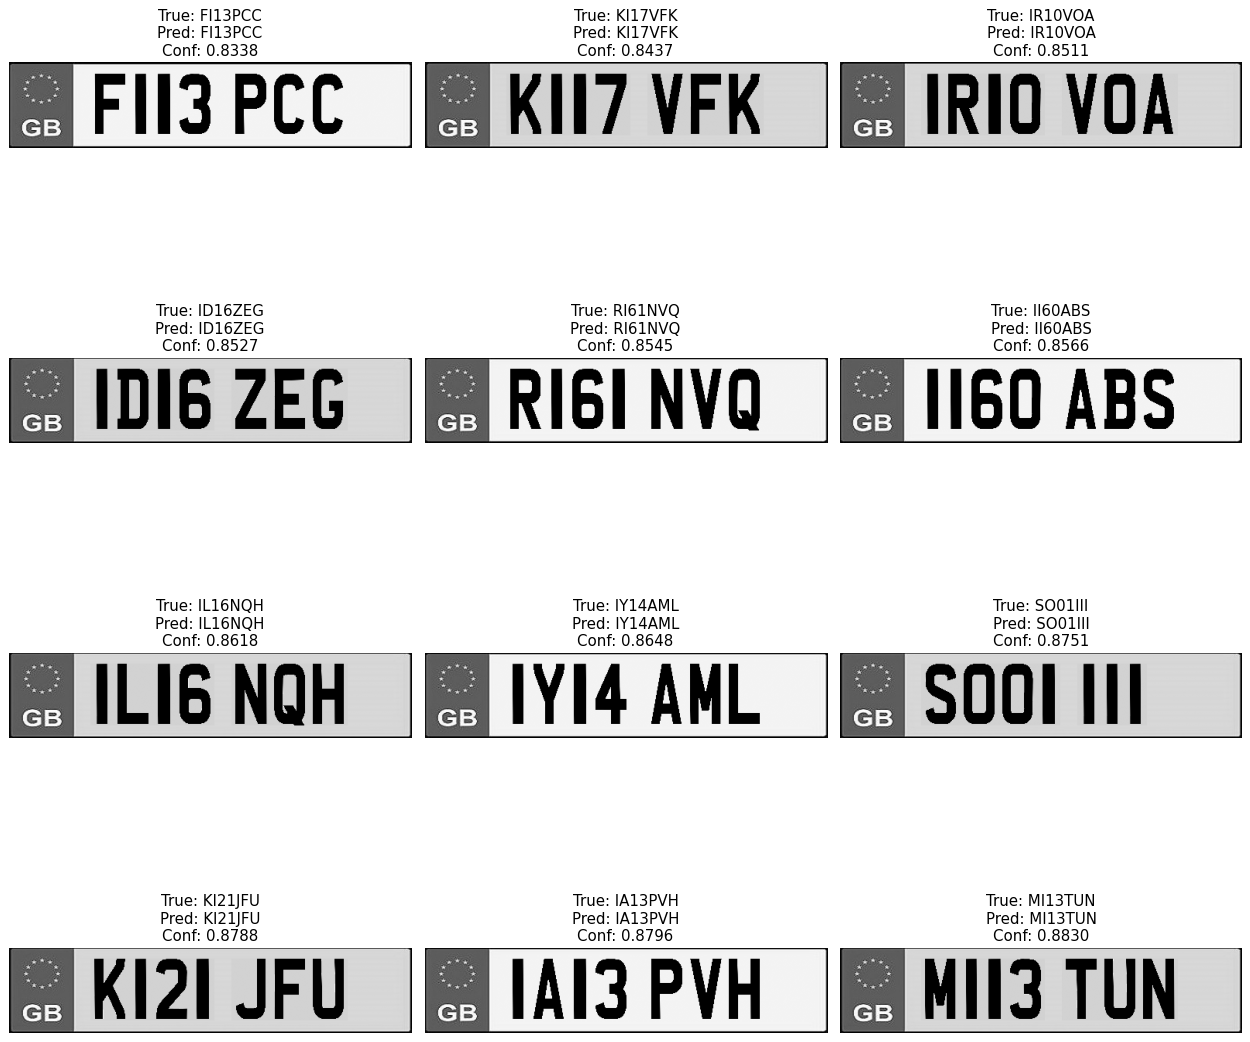

In [9]:
low_conf_correct_df = clean_48_predictions_df[clean_48_predictions_df["correct"]].sort_values("confidence", ascending=True).head(20)
display(low_conf_correct_df[["image_path", "true_label", "predicted_label", "confidence"]])
show_error_images(low_conf_correct_df, max_images=12)


## 4. Augmented 48x160 Baseline


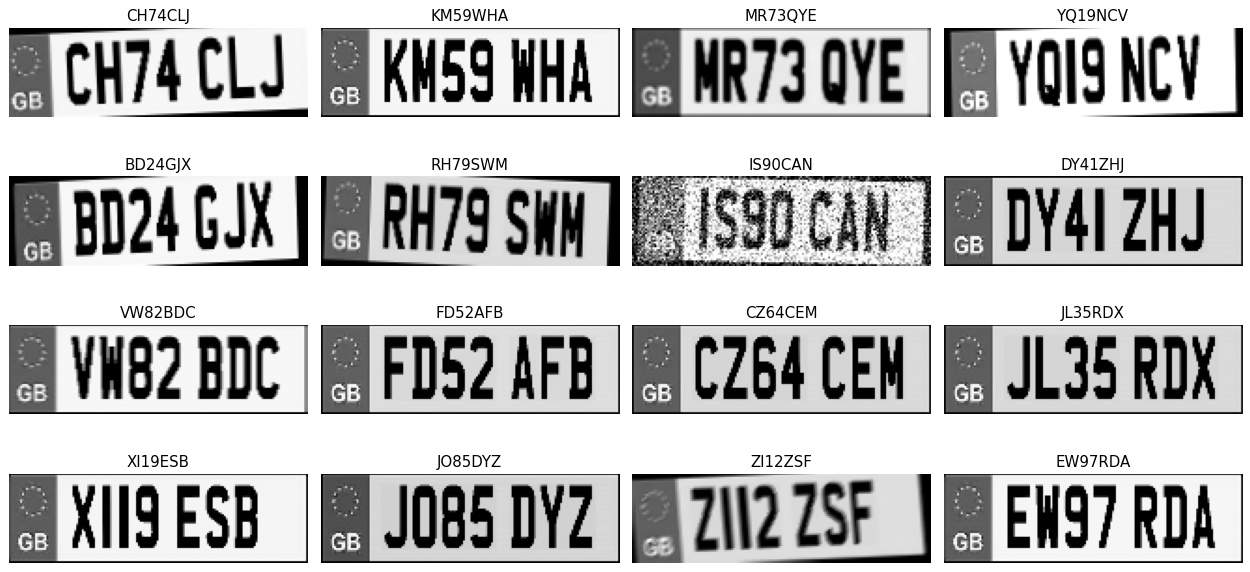

In [10]:
aug_train_ds, aug_val_ds, aug_test_ds = build_datasets(48, 160, train_augmented=True)
show_augmented_batch(aug_train_ds)
aug_train_loader, aug_val_loader, aug_test_loader = make_loaders(aug_train_ds, aug_val_ds, aug_test_ds)


In [12]:
aug_48_model = build_model()
aug_48_checkpoint_path = CHECKPOINT_DIR / "plate_cnn_baseline_aug_best.pt"
aug_48_history_df = train_experiment(aug_48_model, aug_train_loader, aug_val_loader, aug_48_checkpoint_path, 48, 160, num_epochs=5)


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.9465 | val_loss=0.0531 | val_full_plate_acc=0.9750 | confidence=0.9609
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_best.pt


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0389 | val_loss=0.0128 | val_full_plate_acc=0.9879 | confidence=0.9958
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_best.pt


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0312 | val_loss=0.0098 | val_full_plate_acc=0.9917 | confidence=0.9961
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_best.pt


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Augmented 48x160 test loss: 0.011378293324572344
Samples: 2400
Full-plate accuracy: 0.9858
Regex-valid rate: 1.0000
Average confidence: 0.9956
Per-position accuracy:
  Position 0: 1.0000
  Position 1: 0.9996
  Position 2: 0.9992
  Position 3: 0.9988
  Position 4: 0.9950
  Position 5: 0.9938
  Position 6: 0.9950
Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\predictions\baseline_aug_test_predictions.csv


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
0,C:\Users\kosko\OneDrive\Python\machine_learnin...,AA39HMS,AA39HMS,True,0.999800,True,A,A,True,0.999930,...,True,0.999290,M,M,True,0.999983,S,S,True,0.999997
1,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB42XID,AB42XID,True,0.999706,True,A,A,True,0.999917,...,True,0.999970,I,I,True,0.999999,D,D,True,0.999351
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB81EXE,AB81EXE,True,0.999817,True,A,A,True,0.999922,...,True,0.999997,X,X,True,0.999776,E,E,True,0.999913
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB88VEK,AB88VEK,True,0.999841,True,A,A,True,0.999922,...,True,0.999898,E,E,True,0.999683,K,K,True,0.999886
4,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC76RNT,AC76RNT,True,0.999456,True,A,A,True,0.999948,...,True,0.999966,N,N,True,0.996961,T,T,True,0.999898


Number of test errors: 34
Test full-plate accuracy: 0.9858333333333333


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
843,C:\Users\kosko\OneDrive\Python\machine_learnin...,RI61NVQ,RI61VVQ,False,0.971143,True,R,R,True,0.999579,...,False,0.968073,V,V,True,0.849093,Q,Q,True,0.983992
522,C:\Users\kosko\OneDrive\Python\machine_learnin...,KI91SGS,KI91SSS,False,0.962542,True,K,K,True,0.999995,...,True,0.988114,G,S,False,0.768924,S,S,True,0.990348
165,C:\Users\kosko\OneDrive\Python\machine_learnin...,DI91DWP,DI91WWP,False,0.961188,True,D,D,True,0.999456,...,False,0.800675,W,W,True,0.984728,P,P,True,0.959598
1642,C:\Users\kosko\OneDrive\Python\machine_learnin...,JI31ORP,JI31QRP,False,0.952471,True,J,J,True,0.999403,...,False,0.724978,R,R,True,0.991469,P,P,True,0.952083
1584,C:\Users\kosko\OneDrive\Python\machine_learnin...,IC79IYO,IC79IYQ,False,0.947434,True,I,I,True,0.999994,...,True,0.998315,Y,Y,True,0.973494,O,Q,False,0.665403
1990,C:\Users\kosko\OneDrive\Python\machine_learnin...,RI97IEU,RI97ILU,False,0.945646,True,R,R,True,0.999839,...,True,0.997643,E,L,False,0.688507,U,U,True,0.936595
423,C:\Users\kosko\OneDrive\Python\machine_learnin...,II60ABS,II00ABS,False,0.945328,True,I,I,True,0.999968,...,True,0.995866,B,B,True,0.939777,S,S,True,0.998918
2314,C:\Users\kosko\OneDrive\Python\machine_learnin...,YI10DET,YI10EET,False,0.940204,True,Y,Y,True,0.999928,...,False,0.831169,E,E,True,0.971219,T,T,True,0.829861
2280,C:\Users\kosko\OneDrive\Python\machine_learnin...,XO28TVO,XO28TVQ,False,0.938101,True,X,X,True,0.999777,...,True,0.996324,V,V,True,0.999671,O,Q,False,0.573232
2241,C:\Users\kosko\OneDrive\Python\machine_learnin...,WS11KRE,WS11KEE,False,0.933861,True,W,W,True,0.999926,...,True,0.984362,R,E,False,0.556477,E,E,True,0.996648


,position,accuracy,errors
0,0,1.000000,0
1,1,0.999583,1
2,2,0.999167,2
3,3,0.998750,3
4,4,0.995000,12
5,5,0.993750,15
6,6,0.995000,12


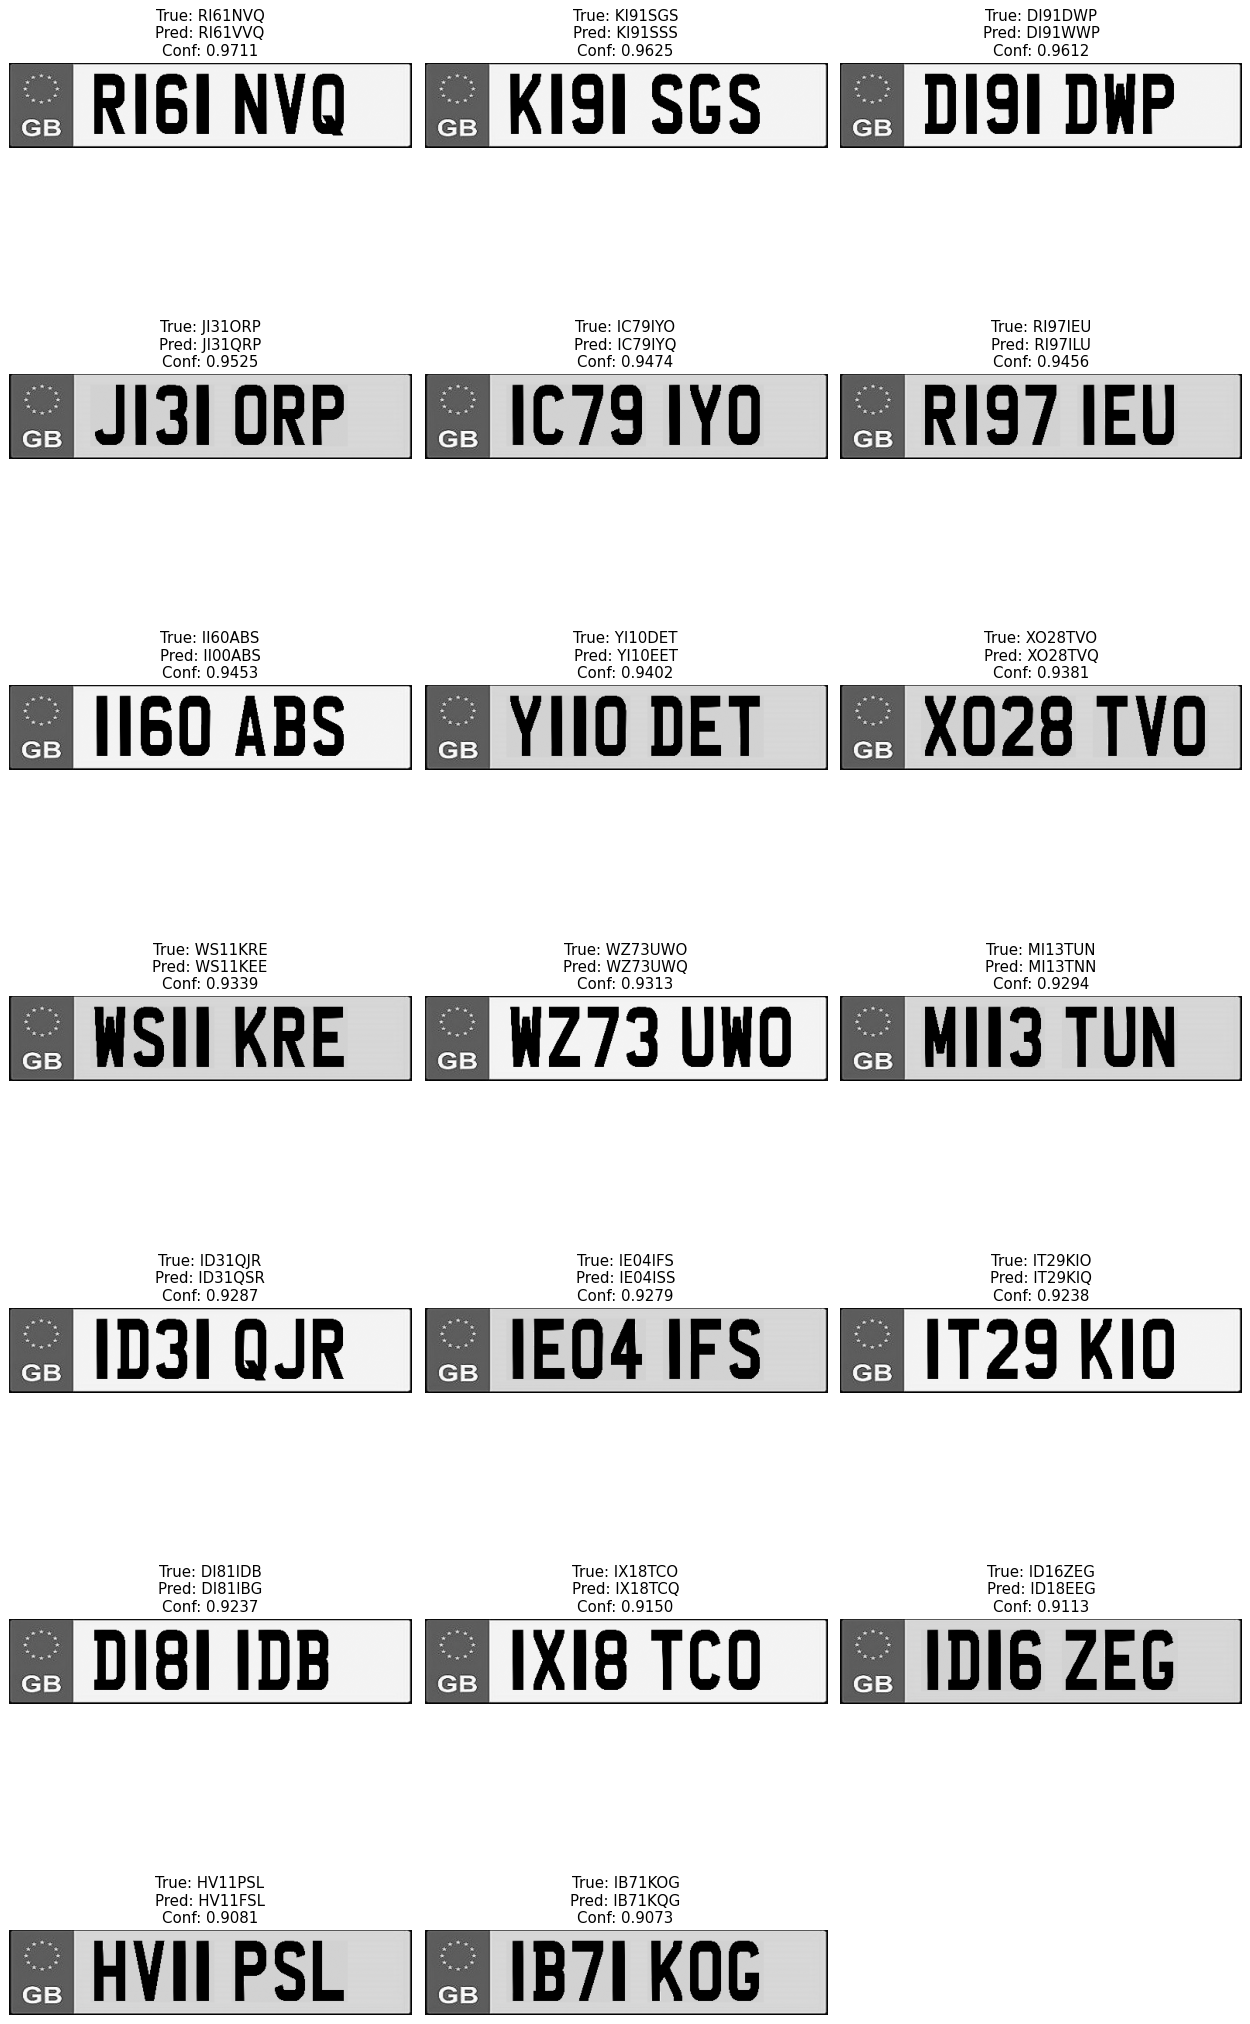

In [13]:
aug_48_best_model, aug_48_checkpoint = load_checkpoint_model(aug_48_checkpoint_path)
aug_48_test_result = evaluate_model(aug_48_best_model, aug_test_loader, "Augmented 48x160 test")
aug_48_predictions_df = export_predictions(aug_48_best_model, aug_test_loader, "baseline_aug_test_predictions.csv")
display(aug_48_predictions_df.head())
display(inspect_errors(aug_48_predictions_df))
display(position_error_summary(aug_48_predictions_df))
aug_48_errors_df = aug_48_predictions_df[~aug_48_predictions_df["correct"]].copy()
show_error_images(aug_48_errors_df.sort_values("confidence", ascending=False), max_images=20)


## 5. Stress Testing 48x160 Models


In [14]:
stress_48_loader = build_stress_loader(48, 160)
evaluate_model(clean_48_best_model, stress_48_loader, "Clean 48x160 stress")
evaluate_model(aug_48_best_model, stress_48_loader, "Augmented 48x160 stress")

experiment_df = pd.DataFrame([
    {"experiment": "clean_48x160", "image_size": "48x160", "train_augmentation": False, "best_val_accuracy": 0.9962, "clean_test_accuracy": 0.9950, "clean_test_errors": 12, "notes": "Best clean baseline. Trained without augmentation."},
    {"experiment": "augmented_48x160", "image_size": "48x160", "train_augmentation": True, "best_val_accuracy": 0.9912, "clean_test_accuracy": 0.9900, "clean_test_errors": 24, "notes": "Lower clean accuracy, needs stress-test comparison."},
])
experiment_df.to_csv(OUTPUT_DIR / "experiment_summary.csv", index=False)
display(experiment_df)


C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:129: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(
C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:134: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Clean 48x160 stress loss: 3.3071561082204184
Samples: 2400
Full-plate accuracy: 0.2437
Regex-valid rate: 1.0000
Average confidence: 0.7113
Per-position accuracy:
  Position 0: 0.3983
  Position 1: 0.4358
  Position 2: 0.5804
  Position 3: 0.4842
  Position 4: 0.3758
  Position 5: 0.4233
  Position 6: 0.4350


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Augmented 48x160 stress loss: 0.07573230197032292
Samples: 2400
Full-plate accuracy: 0.9054
Regex-valid rate: 1.0000
Average confidence: 0.9730
Per-position accuracy:
  Position 0: 0.9925
  Position 1: 0.9904
  Position 2: 0.9917
  Position 3: 0.9942
  Position 4: 0.9721
  Position 5: 0.9550
  Position 6: 0.9663


,experiment,image_size,train_augmentation,best_val_accuracy,clean_test_accuracy,clean_test_errors,notes
0,clean_48x160,48x160,False,0.9962,0.995,12,Best clean baseline. Trained without augmentat...
1,augmented_48x160,48x160,True,0.9912,0.990,24,"Lower clean accuracy, needs stress-test compar..."


In [15]:
clean_48_stress_runs_df = run_repeated_stress_eval(clean_48_best_model, "clean_48x160", stress_48_loader, num_runs=5)
aug_48_stress_runs_df = run_repeated_stress_eval(aug_48_best_model, "augmented_48x160", stress_48_loader, num_runs=5)
stress_48_runs_df = pd.concat([clean_48_stress_runs_df, aug_48_stress_runs_df], ignore_index=True)
stress_48_summary_df = stress_summary(stress_48_runs_df)
save_stress_outputs(stress_48_runs_df, stress_48_summary_df, "stress_test_runs.csv", "stress_test_summary.csv")
display(stress_48_runs_df)
display(stress_48_summary_df)


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

clean_48x160 | run 1 | stress_acc=0.2200 | confidence=0.7039


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

clean_48x160 | run 2 | stress_acc=0.2396 | confidence=0.7128


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

...

augmented_48x160 | run 4 | stress_acc=0.9054 | confidence=0.9738


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

augmented_48x160 | run 5 | stress_acc=0.9067 | confidence=0.9728
Saved: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\predictions\stress_test_runs.csv
Saved: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\predictions\stress_test_summary.csv


,model,run,loss,full_plate_accuracy,regex_valid_rate,average_confidence,position_0_acc,position_1_acc,position_2_acc,position_3_acc,position_4_acc,position_5_acc,position_6_acc
0,clean_48x160,1,3.383825,0.220000,1.0,0.703927,0.391667,0.430000,0.559583,0.482083,0.368333,0.407083,0.417083
1,clean_48x160,2,3.410092,0.239583,1.0,0.712784,0.386667,0.439167,0.573750,0.477500,0.369167,0.398333,0.437917
2,clean_48x160,3,3.385716,0.231667,1.0,0.712081,0.399583,0.427083,0.568333,0.477083,0.370833,0.395417,0.430000
3,clean_48x160,4,3.363112,0.234583,1.0,0.713126,0.408750,0.447500,0.577083,0.475833,0.380000,0.417500,0.432500
4,clean_48x160,5,3.300271,0.233333,1.0,0.708226,0.410417,0.439167,0.571667,0.505417,0.376250,0.418750,0.427917
5,augmented_48x160,1,0.068431,0.905000,1.0,0.972953,0.991667,0.994583,0.991667,0.995000,0.972917,0.959167,0.966250
6,augmented_48x160,2,0.082123,0.899583,1.0,0.972030,0.994167,0.991250,0.992500,0.993750,0.962917,0.953333,0.957917
7,augmented_48x160,3,0.088342,0.891250,1.0,0.971483,0.990417,0.992083,0.992500,0.992083,0.962083,0.946667,0.958750
8,augmented_48x160,4,0.073252,0.905417,1.0,0.973756,0.992500,0.991250,0.994583,0.994583,0.972083,0.957917,0.958333
9,augmented_48x160,5,0.076283,0.906667,1.0,0.972827,0.991667,0.990417,0.993333,0.992500,0.971250,0.958333,0.962500


,model,stress_acc_mean,stress_acc_std,confidence_mean,confidence_std,loss_mean,loss_std
0,augmented_48x160,0.901583,0.006383,0.972610,0.000878,0.077686,0.007755
1,clean_48x160,0.231833,0.007244,0.710029,0.003933,3.368603,0.041670


## 6. Clean and Augmented 64x192 Experiments


In [17]:
clean_64_checkpoint_path = CHECKPOINT_DIR / "plate_cnn_baseline_clean_64x192_best.pt"
aug_64_checkpoint_path = CHECKPOINT_DIR / "plate_cnn_baseline_aug_64x192_best.pt"

In [ ]:
clean_64_train_ds, clean_64_val_ds, clean_64_test_ds = build_datasets(64, 192, train_augmented=False)
clean_64_train_loader, clean_64_val_loader, clean_64_test_loader = make_loaders(clean_64_train_ds, clean_64_val_ds, clean_64_test_ds)
clean_64_model = build_model()

clean_64_history_df = train_experiment(clean_64_model, clean_64_train_loader, clean_64_val_loader, clean_64_checkpoint_path, 64, 192, num_epochs=5)
evaluate_model(clean_64_model, clean_64_test_loader, "Clean 64x192 test")
clean_64_predictions_df = export_predictions(clean_64_model, clean_64_test_loader, "baseline_clean_64x192_test_predictions.csv")
display(clean_64_predictions_df.head())


In [ ]:
aug_64_train_ds, aug_64_val_ds, aug_64_test_ds = build_datasets(64, 192, train_augmented=True)
aug_64_train_loader, aug_64_val_loader, aug_64_test_loader = make_loaders(aug_64_train_ds, aug_64_val_ds, aug_64_test_ds)
aug_64_model = build_model()

aug_64_history_df = train_experiment(aug_64_model, aug_64_train_loader, aug_64_val_loader, aug_64_checkpoint_path, 64, 192, num_epochs=5)
evaluate_model(aug_64_model, aug_64_test_loader, "Augmented 64x192 test")
aug_64_predictions_df = export_predictions(aug_64_model, aug_64_test_loader, "baseline_aug_64x192_test_predictions.csv")
display(aug_64_predictions_df.head())


## 7. Stress Testing 64x192 Models


In [20]:
stress_64_loader = build_stress_loader(64, 192)
clean_64_best_model, clean_64_checkpoint = load_checkpoint_model(clean_64_checkpoint_path)
aug_64_best_model, aug_64_checkpoint = load_checkpoint_model(aug_64_checkpoint_path)
evaluate_model(clean_64_best_model, stress_64_loader, "Clean 64x192 stress")
evaluate_model(aug_64_best_model, stress_64_loader, "Augmented 64x192 stress")
clean_64_stress_runs_df = run_repeated_stress_eval(clean_64_best_model, "clean_64x192", stress_64_loader, num_runs=5)
aug_64_stress_runs_df = run_repeated_stress_eval(aug_64_best_model, "augmented_64x192", stress_64_loader, num_runs=5)
stress_64_runs_df = pd.concat([clean_64_stress_runs_df, aug_64_stress_runs_df], ignore_index=True)
stress_64_summary_df = stress_summary(stress_64_runs_df)
save_stress_outputs(stress_64_runs_df, stress_64_summary_df, "stress_test_64x192_runs.csv", "stress_test_64x192_summary.csv")
display(stress_64_runs_df)
display(stress_64_summary_df)


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Clean 64x192 stress loss: 9.908673235575359
Samples: 2400
Full-plate accuracy: 0.2392
Regex-valid rate: 1.0000
Average confidence: 0.8384
Per-position accuracy:
  Position 0: 0.3621
  Position 1: 0.4158
  Position 2: 0.5537
  Position 3: 0.5458
  Position 4: 0.3975
  Position 5: 0.4050
  Position 6: 0.4458


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Augmented 64x192 stress loss: 0.0631757366657257
Samples: 2400
Full-plate accuracy: 0.9279
Regex-valid rate: 1.0000
Average confidence: 0.9721
Per-position accuracy:
  Position 0: 0.9950
  Position 1: 0.9908
  Position 2: 0.9921
  Position 3: 0.9925
  Position 4: 0.9800
  Position 5: 0.9546
  Position 6: 0.9862


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

...

augmented_64x192 | run 4 | stress_acc=0.9250 | confidence=0.9716


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

augmented_64x192 | run 5 | stress_acc=0.9187 | confidence=0.9700
Saved: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\predictions\stress_test_64x192_runs.csv
Saved: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\predictions\stress_test_64x192_summary.csv


,model,run,loss,full_plate_accuracy,regex_valid_rate,average_confidence,position_0_acc,position_1_acc,position_2_acc,position_3_acc,position_4_acc,position_5_acc,position_6_acc
0,clean_64x192,1,10.149809,0.236250,1.0,0.840765,0.351667,0.410833,0.560833,0.537500,0.399583,0.399167,0.450000
1,clean_64x192,2,10.192714,0.229583,1.0,0.836973,0.355833,0.402500,0.554167,0.531250,0.389167,0.401667,0.450000
2,clean_64x192,3,10.129083,0.237500,1.0,0.839964,0.350417,0.415417,0.553750,0.541250,0.405000,0.412917,0.453333
3,clean_64x192,4,10.137911,0.229167,1.0,0.836759,0.352917,0.400833,0.558333,0.540417,0.395417,0.388333,0.436667
4,clean_64x192,5,9.963496,0.243750,1.0,0.841181,0.364167,0.411667,0.576250,0.549167,0.401667,0.412500,0.459167
5,augmented_64x192,1,0.064115,0.922083,1.0,0.968564,0.989583,0.990417,0.992500,0.994167,0.981250,0.952083,0.985833
6,augmented_64x192,2,0.062508,0.932083,1.0,0.970498,0.990833,0.991667,0.992500,0.994167,0.985417,0.958750,0.988750
7,augmented_64x192,3,0.066083,0.922083,1.0,0.969074,0.989583,0.991250,0.989583,0.991667,0.981667,0.958750,0.984583
8,augmented_64x192,4,0.055763,0.925000,1.0,0.971582,0.994583,0.990417,0.991250,0.995417,0.983750,0.958750,0.986250
9,augmented_64x192,5,0.063083,0.918750,1.0,0.970014,0.992500,0.993333,0.990000,0.991667,0.982500,0.951667,0.987083


,model,stress_acc_mean,stress_acc_std,confidence_mean,confidence_std,loss_mean,loss_std
0,augmented_64x192,0.92400,0.005031,0.969946,0.001189,0.062310,0.003905
1,clean_64x192,0.23525,0.006071,0.839128,0.002113,10.114603,0.087931


## 8. API-Flow and Legacy Integration Checks

These cells preserve late project-building checks. The Roboflow simulation cells depend on older runtime helpers and should be run only when those helpers are available.


In [22]:
from pathlib import Path
import pandas as pd

from anpr.inference.predict import PlateRecognizer


PROJECT_ROOT = Path("..").resolve()

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "baseline_cnn"
    / "plate_cnn_baseline_aug_best.pt"
)

recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
)

test_predictions_path = (
    PROJECT_ROOT
    / "outputs"
    / "predictions"
    / "baseline_test_predictions.csv"
)

test_predictions_df = pd.read_csv(test_predictions_path)

sample_row = test_predictions_df.iloc[0]
image_path = sample_row["image_path"]

prediction = recognizer.predict_image(image_path)

print("Image:", image_path)
print("True label:", sample_row["true_label"])
print("Prediction:", prediction.cleaned_prediction)
print("Valid format:", prediction.is_valid_format)
print("Confidence:", prediction.overall_confidence)
print("Position confidences:", prediction.position_confidences)

Image: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA39HMS.png
True label: AA39HMS
Prediction: AA39HMS
Valid format: True
Confidence: 0.9998662386621747
Position confidences: [0.9999315738677979, 0.9999909400939941, 0.9998929500579834, 0.9998278617858887, 0.999446451663971, 0.9999797344207764, 0.999994158744812]


In [23]:
path = PROJECT_ROOT / "checkpoints" / "baseline_cnn" / "plate_cnn_baseline_aug_best.pt"
img_path = PROJECT_ROOT / "data" / "raw" / "plate_crops" / "white" / "AA03BOJ.png"
recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=path,
    device="cpu",
)

prediction = recognizer.predict_image(img_path)

print(prediction.cleaned_prediction)
print(prediction.is_valid_format)
print(prediction.overall_confidence)

AA03BOJ
True
0.9946397968700954


### Legacy Roboflow Simulation Checks


In [ ]:
roboflow_prediction = {
    "x": 60, # random
    "y": 200, # random
    "width": 60, # random
    "height": 200, #random
}

prediction = recognizer.predict_from_roboflow_crop(
    image_path=img_path,
    prediction=roboflow_prediction,
    padding=0.05,
)

print(prediction.cleaned_prediction)
print(prediction.is_valid_format)
print(prediction.overall_confidence)

In [27]:
CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "baseline_cnn"
    / "plate_cnn_baseline_aug_best.pt"
)

recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
)

sample = clean_test_ds[0]

prediction = recognizer.predict_image(sample["image_path"])

print("True:", sample["label"])
print("Pred:", prediction.cleaned_prediction)
print("Valid:", prediction.is_valid_format)
print("Confidence:", prediction.overall_confidence)

True: AA39HMS
Pred: AA39HMS
Valid: True
Confidence: 0.9998662386621747


In [28]:
import cv2

image = cv2.imread(sample["image_path"], cv2.IMREAD_COLOR)

prediction = recognizer.predict_array(image)

print("True:", sample["label"])
print("Pred:", prediction.cleaned_prediction)
print("Valid:", prediction.is_valid_format)
print("Confidence:", prediction.overall_confidence)

True: AA39HMS
Pred: AA39HMS
Valid: True
Confidence: 0.9998663067817688


In [30]:
CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "baseline_cnn"
    / "plate_cnn_baseline_aug_best.pt"
)

recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
)

sample = clean_test_ds[0]

result = recognizer.predict_image_report(
    image_path=sample["image_path"],
    min_overall_confidence=0.80,
    min_position_confidence=0.60,
)

print("True:", sample["label"])
print(result)
print(result.to_dict())

True: AA39HMS
PlateRecognitionResult(plate='AA39HMS', raw_prediction='AA39HMS', valid_format=True, overall_confidence=0.9998662386621747, position_confidences=[0.9999315738677979, 0.9999909400939941, 0.9998929500579834, 0.9998278617858887, 0.999446451663971, 0.9999797344207764, 0.999994158744812], low_confidence_positions=[], should_accept=True, rejection_reasons=[])
{'plate': 'AA39HMS', 'raw_prediction': 'AA39HMS', 'valid_format': True, 'overall_confidence': 0.9998662386621747, 'position_confidences': [0.9999315738677979, 0.9999909400939941, 0.9998929500579834, 0.9998278617858887, 0.999446451663971, 0.9999797344207764, 0.999994158744812], 'low_confidence_positions': [], 'should_accept': True, 'rejection_reasons': []}


In [31]:
from anpr.inference.pipeline import ANPRPipeline

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "baseline_cnn"
    / "plate_cnn_baseline_aug_best.pt"
)

pipeline = ANPRPipeline.from_checkpoint(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    min_overall_confidence=0.80,
    min_position_confidence=0.60,
)

sample = clean_test_ds[0]

result = pipeline.predict_cropped_image(sample["image_path"])

print("True:", sample["label"])
print(result.to_dict())

True: AA39HMS
{'plate': 'AA39HMS', 'valid_format': True, 'overall_confidence': 0.9998662386621747, 'should_accept': True, 'rejection_reasons': [], 'detection_confidence': None, 'crop_padding': 0.0, 'recognition': {'plate': 'AA39HMS', 'raw_prediction': 'AA39HMS', 'valid_format': True, 'overall_confidence': 0.9998662386621747, 'position_confidences': [0.9999315738677979, 0.9999909400939941, 0.9998929500579834, 0.9998278617858887, 0.999446451663971, 0.9999797344207764, 0.999994158744812], 'low_confidence_positions': [], 'should_accept': True, 'rejection_reasons': []}, 'detection': None}


In [ ]:
import cv2

sample = clean_test_ds[0]
image_path = sample["image_path"]

image = cv2.imread(image_path)
height, width = image.shape[:2]

fake_roboflow_response = {
    "predictions": [
        {
            "x": width / 2,
            "y": height / 2,
            "width": width,
            "height": height,
            "confidence": 0.99,
            "class": "license_plate",
        }
    ]
}

result = pipeline.predict_full_image_from_roboflow_response(
    image_path=image_path,
    roboflow_response=fake_roboflow_response,
    crop_padding=0.0,
)

print("True:", sample["label"])
print(result.to_dict())

## 9. Dataset Diagnostics and Debug Utilities


In [32]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates.csv"

df = pd.read_csv(METADATA_CSV)

for position in range(7):
    print(f"\nPosition {position}")
    print(df["label"].str[position].value_counts().sort_index())

print("\nSpecific real-plate characters:")
print("Position 0 == R:", (df["label"].str[0] == "R").sum())
print("Position 1 == V:", (df["label"].str[1] == "V").sum())
print("Position 6 == T:", (df["label"].str[6] == "T").sum())


Position 0
label
A    917
B    949
C    892
D    970
E    906
F    936
G    918
H    983
I    918
J    894
K    954
L    887
M    926
N    882
O    917
P    960
Q    897
R    925
S    942
T    919
U    872
V    927
W    898
X    899
Y    940
Z    972
Name: count, dtype: int64

Position 1
label
A    945
B    950
C    916
D    875
E    934
F    883
G    894
H    968
I    933
J    917
K    971
L    955
M    954
N    877
O    892
P    857
Q    954
R    866
S    998
T    922
U    902
V    953
W    885
X    966
Y    899
Z    934
Name: count, dtype: int64

Position 2
label
0    2423
1    2294
2    2412
3    2417
4    2508
5    2417
6    2380
7    2447
8    2363
9    2339
Name: count, dtype: int64

Position 3
label
0    2409
1    2300
2    2406
3    2408
4    2440
5    2444
6    2367
7    2481
8    2413
9    2332
Name: count, dtype: int64

Position 4
label
A    911
B    924
C    970
D    954
E    902
F    896
G    915
H    926
I    914
J    905
K    918
L    889
M    927
N    955
O    962
P  

In [36]:
from pathlib import Path

from anpr.inference.predict import PlateRecognizer

best_model_path = PROJECT_ROOT / "checkpoints"/ "baseline_cnn" / "plate_cnn_final.pt"
model_64x192_path = PROJECT_ROOT / "checkpoints"/ "baseline_cnn" / "plate_cnn_baseline_aug_64x192_best.pt"
# Path("uk_plate_recognition/checkpoints/baseline_cnn/plate_cnn_baseline_best.pt")

checkpoint_paths = {
    "aug_48x160": best_model_path,
    "aug_64x192": model_64x192_path,
}

crop_paths = [
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA03BOJ.png"),
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA06OHE.png"),
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA15VJJ.png"),
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA19HSV.png"),
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA22JTE.png"),
]

for model_name, checkpoint_path in checkpoint_paths.items():
    recognizer = PlateRecognizer.from_checkpoint(
        checkpoint_path=checkpoint_path,
        device=DEVICE,
    )

    print(f"\nMODEL: {model_name}")

    for crop_path in crop_paths:
        result = recognizer.predict_image_report(
            crop_path,
            min_overall_confidence=0.80,
            min_position_confidence=0.60,
        )

        print(
            crop_path.name,
            "| plate:", result.plate,
            "| accept:", result.should_accept,
            "| conf:", round(result.overall_confidence, 4),
            "| low:", result.low_confidence_positions,
        )


MODEL: aug_48x160
AA03BOJ.png | plate: AA03BOJ | accept: True | conf: 0.9991 | low: []
AA06OHE.png | plate: AA06OHE | accept: True | conf: 0.9996 | low: []
AA15VJJ.png | plate: AA15VJJ | accept: True | conf: 0.9993 | low: []
AA19HSV.png | plate: AA19HSV | accept: True | conf: 0.9995 | low: []
AA22JTE.png | plate: AA22JTE | accept: True | conf: 0.9997 | low: []

MODEL: aug_64x192
AA03BOJ.png | plate: AA03BBJ | accept: True | conf: 0.9518 | low: []
AA06OHE.png | plate: AA06CHE | accept: False | conf: 0.9384 | low: [4]
AA15VJJ.png | plate: AA15VJJ | accept: True | conf: 0.9988 | low: []
AA19HSV.png | plate: AA19HSV | accept: True | conf: 0.9985 | low: []
AA22JTE.png | plate: AA22JTE | accept: True | conf: 0.9965 | low: []


In [37]:
import torch

from anpr.data.encoders import INDEX_TO_CHAR
from anpr.inference.predict import PlateRecognizer


def debug_topk_predictions(
    recognizer: PlateRecognizer,
    image_path,
    k: int = 5,
):
    image = recognizer._load_image(image_path)
    image_tensor = recognizer._prepare_image_tensor(image)

    recognizer.model.eval()

    with torch.no_grad():
        outputs = recognizer.model(image_tensor)

    for position, logits in enumerate(outputs):
        probs = torch.softmax(logits, dim=1)[0]
        top_probs, top_indices = torch.topk(probs, k=k)

        decoded = [
            (INDEX_TO_CHAR[position][int(index.item())], float(prob.item()))
            for index, prob in zip(top_indices, top_probs)
        ]

        print(f"Position {position}: {decoded}")

In [38]:
recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=model_64x192_path,
    device="cpu",
)

debug_topk_predictions(
    recognizer,
    r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA03BOJ.png",
    k=5,
)

Position 0: [('A', 0.9999946355819702), ('X', 4.7827288653934374e-06), ('Z', 1.8901667431237001e-07), ('V', 1.3022817313412816e-07), ('L', 1.0783195136809809e-07)]
Position 1: [('A', 0.9999936819076538), ('X', 6.212456355569884e-06), ('I', 6.018516529593398e-08), ('N', 2.5155996397074887e-08), ('W', 2.475928262413163e-08)]
Position 2: [('0', 0.9902737736701965), ('3', 0.004779502749443054), ('1', 0.002987595507875085), ('7', 0.0008865153067745268), ('8', 0.0007181431283243)]
Position 3: [('3', 0.9999921321868896), ('5', 6.209236744325608e-06), ('9', 1.3735788115809555e-06), ('7', 2.2505021490815125e-07), ('4', 2.2577843594717706e-08)]
Position 4: [('B', 0.9582535624504089), ('Z', 0.011703641153872013), ('A', 0.011041564866900444), ('W', 0.010424395091831684), ('E', 0.004151586908847094)]
Position 5: [('B', 0.7149538993835449), ('O', 0.10106559842824936), ('X', 0.07588998973369598), ('G', 0.028917716816067696), ('C', 0.01884700544178486)]
Position 6: [('J', 0.9993984699249268), ('Q', 0.

### Clean Cropped Dataset Report


In [ ]:
CLEAN_CROP_DIR = PROJECT_ROOT / "data" / "raw" / "plate_crops_verified_format"
OUTPUT_REPORT_DIR = PROJECT_ROOT / "outputs" / "real_crop_dataset_report"
OUTPUT_REPORT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}
PLATE_PATTERN = re.compile(r"^([A-Z]{2}[0-9]{2}[A-Z]{3})", re.IGNORECASE)

def extract_plate_label(path: Path) -> str | None:
    match = PLATE_PATTERN.match(path.stem.upper())
    return match.group(1) if match else None

def file_digest(path: Path) -> str:
    hasher = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

def build_clean_crop_report(crop_dir: Path) -> pd.DataFrame:
    rows = []
    for image_path in sorted(crop_dir.rglob("*")):
        if not image_path.is_file() or image_path.suffix.lower() not in REPORT_IMAGE_EXTENSIONS:
            continue
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        height, width = image.shape[:2] if image is not None else (None, None)
        rows.append({
            "image_path": str(image_path),
            "filename": image_path.name,
            "label": extract_plate_label(image_path),
            "valid_label": extract_plate_label(image_path) is not None,
            "width": width,
            "height": height,
            "sha256": file_digest(image_path),
        })
    return pd.DataFrame(rows)

if CLEAN_CROP_DIR.exists():
    report_df = build_clean_crop_report(CLEAN_CROP_DIR)
    report_path = OUTPUT_REPORT_DIR / "clean_crop_report.csv"
    report_df.to_csv(report_path, index=False)
    display(Markdown("# Clean Cropped UK License Plate Dataset Report"))
    print("Crop directory:", CLEAN_CROP_DIR)
    print("Total images:", len(report_df))
    print("Valid labels:", report_df["valid_label"].sum())
    print("Duplicate files:", report_df["sha256"].duplicated().sum())
    print("Saved report:", report_path)
    display(report_df.head())
else:
    print("Clean crop directory does not exist:", CLEAN_CROP_DIR)


# Clean Cropped UK License Plate Dataset Report

Crop directory: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops_verified_format
Total images: 38472
Valid labels: 38472
Duplicate files: 20559
Saved report: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\real_crop_dataset_report\clean_crop_report.csv


,image_path,filename,label,valid_label,width,height,sha256
0,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC08UHJ.jpg,AC08UHJ,True,102,25,f5c648a0aa6a4d9b7db6f4088140a884a91923e06abee1...
1,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC08UHJ_002.jpg,AC08UHJ,True,71,18,d93c53c9cdc04ab5945a8be477545acebb545c2ba953c9...
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC08UHJ_003.jpg,AC08UHJ,True,102,25,f5c648a0aa6a4d9b7db6f4088140a884a91923e06abee1...
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC08UHJ_004.jpg,AC08UHJ,True,71,18,d93c53c9cdc04ab5945a8be477545acebb545c2ba953c9...
4,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC08UHJ_005.jpg,AC08UHJ,True,102,25,f5c648a0aa6a4d9b7db6f4088140a884a91923e06abee1...
